In [3]:
import pandas as pd


In [4]:
df=pd.read_csv("Houseprice.csv")

In [5]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41,6.984127,1.023810,322,2.555556,37.88,-122.23,4.526
1,8.3014,21,6.238137,0.971880,2401,2.109842,37.86,-122.22,3.585
2,7.2574,52,8.288136,1.073446,496,2.802260,37.85,-122.24,3.521
3,5.6431,52,5.817352,1.073059,558,2.547945,37.85,-122.25,3.413
4,3.8462,52,6.281853,1.081081,565,2.181467,37.85,-122.25,3.422


In [6]:
df.shape

(20640, 9)

In [7]:
df.isna().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
HousePrice    0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(0)

<Axes: xlabel='Population'>

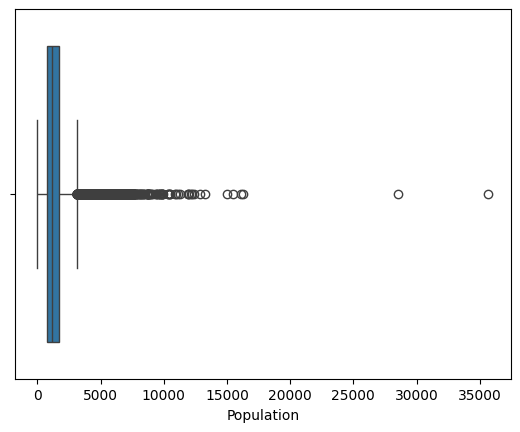

In [15]:
import seaborn as sns
sns.boxplot(df,x='Population')

In [16]:
df=df[df['Population']<df['Population'].quantile(0.95)]

<Axes: xlabel='Population'>

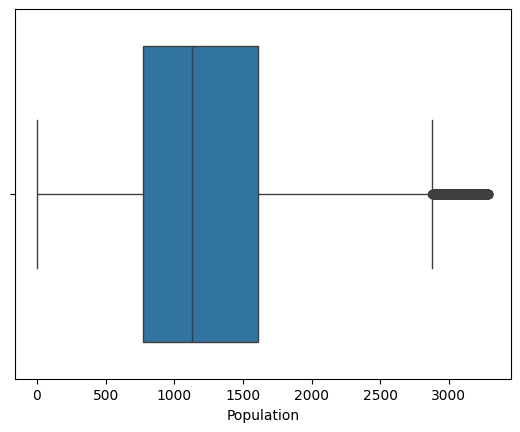

In [17]:
sns.boxplot(df,x='Population')

<Axes: xlabel='AveRooms'>

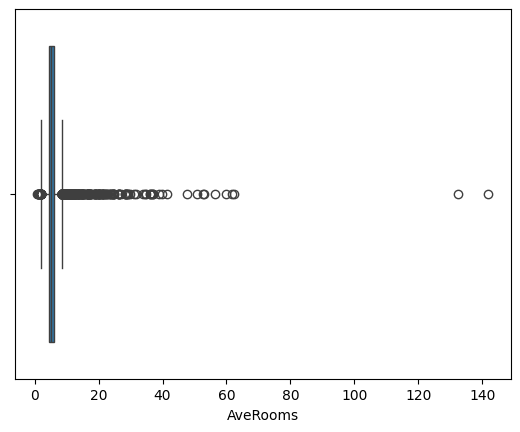

In [18]:
sns.boxplot(df,x='AveRooms')

In [19]:
df=df[df['AveRooms']<df['AveRooms'].quantile(0.95)]

<Axes: xlabel='AveRooms'>

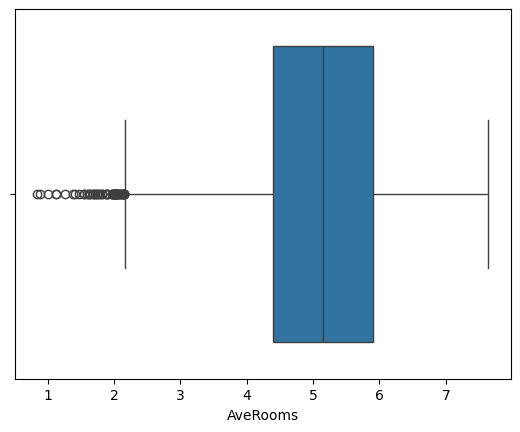

In [20]:
sns.boxplot(df,x='AveRooms')

<Axes: xlabel='Latitude'>

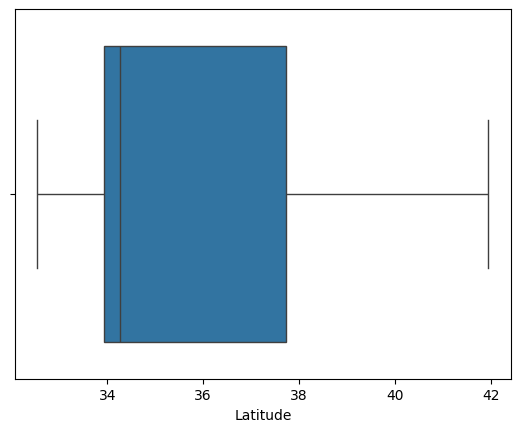

In [21]:
sns.boxplot(df,x='Latitude')

<Axes: xlabel='Longitude'>

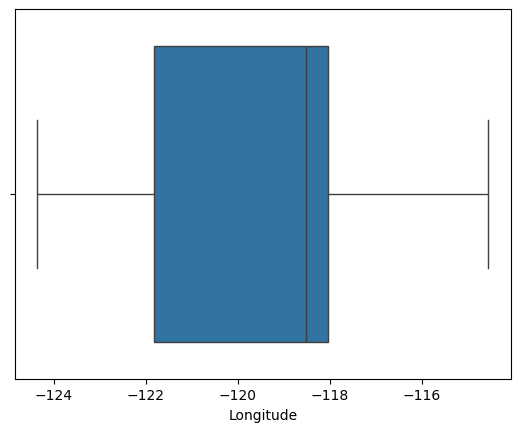

In [22]:
sns.boxplot(df,x='Longitude')

<Axes: xlabel='AveOccup'>

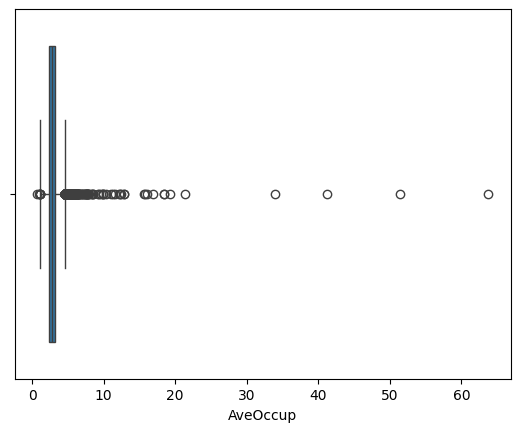

In [23]:
sns.boxplot(df,x='AveOccup')

In [24]:
df = df[df['AveOccup']<df['AveOccup'].quantile(0.95)]

<Axes: xlabel='AveOccup'>

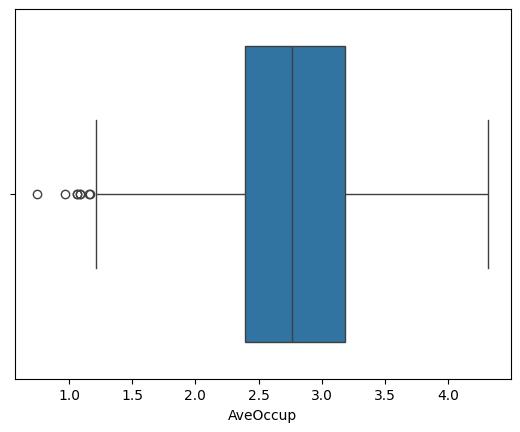

In [25]:
sns.boxplot(df,x='AveOccup')

In [8]:
X = df.drop('HousePrice',axis=1)

In [9]:
y = df['HousePrice']

In [10]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [11]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train)
X_test_sc = sc.transform(X_test)

In [12]:
from sklearn.linear_model import Ridge, LinearRegression, Lasso
import numpy as np
model= Ridge()
params={
    'alpha': np.logspace(-3,1, num=50)
}

In [13]:
from sklearn.model_selection import GridSearchCV
grid=GridSearchCV(model,params,cv=10)
grid.fit(X_train_sc,y_train)

,estimator,Ridge()
,param_grid,{'alpha': array([1.0000...00000000e+01])}
,scoring,None
,n_jobs,None
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,np.float64(1.5264179671752318)


In [14]:
model=grid.best_estimator_

In [15]:
ypred=model.predict(X_test_sc)

In [16]:
ypred

array([0.71965595, 1.76375736, 2.70912498, ..., 4.46832194, 1.1882139 ,
       2.00912482])

In [17]:
from sklearn.metrics import r2_score

In [18]:
print(r2_score(y_test,ypred))

0.5758304281755515
